# Notebook 4 — Exploratory Data Analysis

## 1. Loading and Initial Inspection

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("../data/artifacts/train.csv")
train.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,customer_state,total_items,total_price,total_freight,unique_products,unique_sellers,total_payments,payment_count,payment_types,late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,...,SP,3.0,134.97,8.49,1.0,1.0,NaN,NaN,NaN,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,32ea3bdedab835c3aa6cb68ce66565ef,4106,...,SP,1.0,29.90,15.56,1.0,1.0,45.46,1.0,1.0,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2f64e403852e6893ae37485d5fcacdaf,98280,...,RS,1.0,21.90,17.19,1.0,1.0,39.09,1.0,1.0,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,b8b8726af116a5cfb35b0315ecef9172,22770,...,RJ,1.0,21.50,14.11,1.0,1.0,35.61,1.0,1.0,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,61db744d2f835035a5625b59350c6b63,90040,...,RS,1.0,36.49,17.24,1.0,1.0,53.73,1.0,1.0,0


In [90]:
print("Shape:", train.shape)
print("Rows:", train.shape[0])
print("Columns:", train.shape[1])
print("Duplicate rows:", train.duplicated().sum())
print("Unique orders:", train["order_id"].nunique())

Shape: (67533, 27)
Rows: 67533
Columns: 27


Duplicate rows: 0
Unique orders: 67533


In [91]:
dtype_summary = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values
})

dtype_summary

,column,dtype
0,order_id,str
1,customer_id,str
2,order_status,str
3,order_purchase_timestamp,datetime64[us]
4,order_approved_at,datetime64[us]
5,order_delivered_carrier_date,datetime64[us]
6,order_delivered_customer_date,datetime64[us]
7,order_estimated_delivery_date,datetime64[us]
8,customer_unique_id,str
9,customer_zip_code_prefix,int64


In [92]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67533 non-null  str           
 1   customer_id                    67533 non-null  str           
 2   order_status                   67533 non-null  str           
 3   order_purchase_timestamp       67533 non-null  datetime64[us]
 4   order_approved_at              67519 non-null  datetime64[us]
 5   order_delivered_carrier_date   67532 non-null  datetime64[us]
 6   order_delivered_customer_date  67533 non-null  datetime64[us]
 7   order_estimated_delivery_date  67533 non-null  datetime64[us]
 8   customer_unique_id             67533 non-null  str           
 9   customer_zip_code_prefix       67533 non-null  int64         
 10  customer_city                  67533 non-null  str           
 11  customer_state            

In [93]:
duplicate_rows = train.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


### 1.1 ID and Duplicate Checks

In [94]:
id_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

for col in id_columns:
    print(f"{col}:")
    print("  Unique values:", train[col].nunique())
    print("  Total rows:", len(train))
    print("  Duplicated values:", train[col].duplicated().sum())
    print()

order_id:
  Unique values: 67533
  Total rows: 67533
  Duplicated values: 0

customer_id:
  Unique values: 67533
  Total rows: 67533
  Duplicated values: 0

customer_unique_id:
  Unique values: 65401
  Total rows: 67533
  Duplicated values: 2132



### 1.2 Target Distribution

In [132]:
target_counts = train["late"].value_counts().sort_index()
target_percent = train["late"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent.round(2)
})

target_summary

,count,percentage
late,,
0,61436,90.97
1,6097,9.03


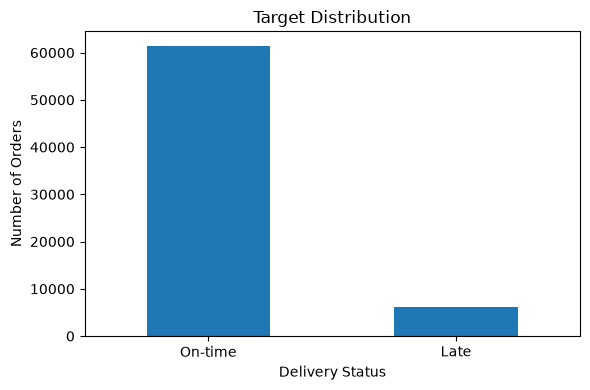

In [133]:
train["late"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Target Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks([0, 1], ["On-time", "Late"], rotation=0)
plt.tight_layout()
plt.show()

## 2. Missing Value Analysis

In [134]:
missing = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percentage": train.isna().mean() * 100
})

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

missing

,missing_count,missing_percentage
order_approved_at,14,0.020731
order_delivered_carrier_date,1,0.001481
payment_types,1,0.001481
payment_count,1,0.001481
total_payments,1,0.001481
order_id,0,0.000000
unique_products,0,0.000000
purchase_year_month,0,0.000000
purchase_hour,0,0.000000
purchase_weekday,0,0.000000


## 3. Numerical Feature Analysis

In [135]:
numerical_columns = [
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "total_payments",
    "payment_count",
    "payment_types"
]

train[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
total_items,67533.0,1.142079,0.541635,1.00,1.00,1.00,1.000,21.00
total_price,67533.0,135.884499,205.187627,2.29,45.90,85.00,149.900,13440.00
total_freight,67533.0,22.244256,19.999582,0.00,14.10,16.79,23.700,1002.29
unique_products,67533.0,1.037715,0.222223,1.00,1.00,1.00,1.000,7.00
unique_sellers,67533.0,1.012053,0.114812,1.00,1.00,1.00,1.000,5.00
total_payments,67532.0,158.167657,214.277783,10.07,61.63,104.19,175.485,13664.08
payment_count,67532.0,1.047622,0.397212,1.00,1.00,1.00,1.000,26.00
payment_types,67532.0,1.024018,0.153107,1.00,1.00,1.00,1.000,2.00


In [136]:
skewness = train[numerical_columns].skew().sort_values(ascending=False)

skewness

payment_count      22.420165
total_price        10.719309
unique_sellers     10.525258
total_payments     10.149896
total_freight       8.584291
total_items         8.106935
unique_products     7.675360
payment_types       6.217825
dtype: float64

### 3.1 Numerical Feature Distributions

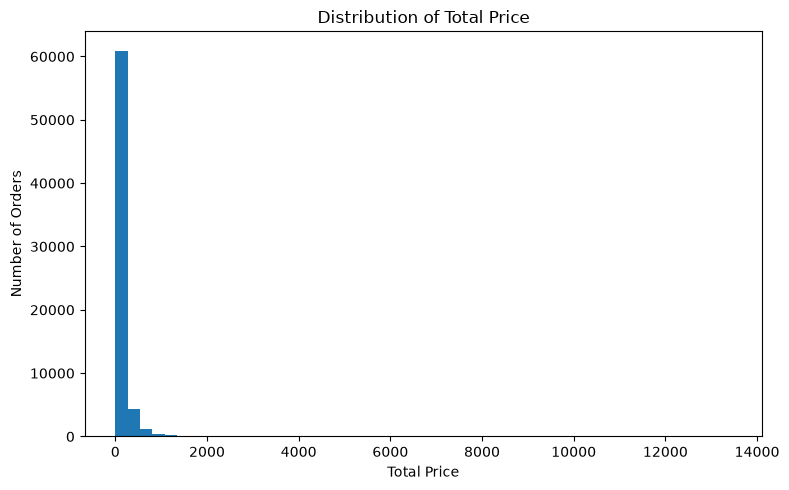

In [137]:
plt.figure(figsize=(8, 5))

plt.hist(train["total_price"], bins=50)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### 3.2 Feature Value Analysis

In [138]:
for col in numerical_columns:
    print(f"\n--- {col} ---")
    print(train[col].value_counts().head(10))


--- total_items ---
total_items
1.0     60774
2.0      5201
3.0       903
4.0       363
5.0       134
6.0       115
7.0        13
8.0         8
10.0        6
11.0        3
Name: count, dtype: int64

--- total_price ---
total_price
59.9    1442
69.9    1171
89.9    1017
49.9     987
99.9     816
39.9     734
19.9     718
29.9     669
49.0     645
79.9     625
Name: count, dtype: int64

--- total_freight ---
total_freight
15.10    2891
7.78     1795
14.10    1483
11.85    1419
16.11     777
8.72      721
16.79     677
14.52     651
10.96     568
18.23     505
Name: count, dtype: int64

--- unique_products ---
unique_products
1.0    65323
2.0     1949
3.0      204
4.0       47
6.0        7
5.0        2
7.0        1
Name: count, dtype: int64

--- unique_sellers ---
unique_sellers
1.0    66757
2.0      742
3.0       31
4.0        2
5.0        1
Name: count, dtype: int64

--- total_payments ---
total_payments
77.57     250
35.00     164
73.34     161
116.94    131
107.78    117
56.78     11

### 3.3 Order Item Analysis

In [139]:
single_item_pct = (train["total_items"] == 1).mean() * 100
print(f"Single-item orders: {single_item_pct:.2f}%")

Single-item orders: 89.99%


## 4. Outlier Analysis

In [140]:
outlier_summary = []

for col in numerical_columns:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((train[col] < lower) | (train[col] > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outliers,
        "outlier_percentage": outliers / len(train) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "outlier_percentage",
    ascending=False
)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,total_items,1.00,1.000,0.000,1.0000,1.0000,6759,10.008440
2,total_freight,14.10,23.700,9.600,-0.3000,38.1000,6629,9.815942
1,total_price,45.90,149.900,104.000,-110.1000,305.9000,5361,7.938341
5,total_payments,61.63,175.485,113.855,-109.1525,346.2675,5308,7.859861
3,unique_products,1.00,1.000,0.000,1.0000,1.0000,2210,3.272474
6,payment_count,1.00,1.000,0.000,1.0000,1.0000,2129,3.152533
7,payment_types,1.00,1.000,0.000,1.0000,1.0000,1622,2.401789
4,unique_sellers,1.00,1.000,0.000,1.0000,1.0000,776,1.149068


## 5. Feature Comparison by Delivery Status

In [141]:
late_comparison = train.groupby("late")[numerical_columns].agg(
    ["mean", "median"]
)

late_comparison

total_items        total_price        total_freight         \
            mean median        mean median          mean median   
late                                                              
0       1.144834    1.0  134.506741  84.99     21.950632  16.60   
1       1.114319    1.0  149.767376  89.99     25.202941  18.12   

     unique_products        unique_sellers        total_payments           \
                mean median           mean median           mean   median   
late                                                                        
0           1.039228    1.0       1.012989    1.0     156.496706  103.050   
1           1.022470    1.0       1.002624    1.0     175.007633  113.855   

     payment_count        payment_types         
              mean median          mean median  
late                                            
0         1.048359    1.0      1.024367    1.0  
1         1.040190    1.0      1.020505    1.0

In [142]:
late_counts = train.groupby("late")[numerical_columns].mean().T

late_counts["difference"] = (
    late_counts[1] - late_counts[0]
)

late_counts.sort_values(
    "difference",
    ascending=False
)

late,0,1,difference
total_payments,156.496706,175.007633,18.510927
total_price,134.506741,149.767376,15.260634
total_freight,21.950632,25.202941,3.252309
payment_types,1.024367,1.020505,-0.003862
payment_count,1.048359,1.040190,-0.008169
unique_sellers,1.012989,1.002624,-0.010365
unique_products,1.039228,1.022470,-0.016758
total_items,1.144834,1.114319,-0.030515


### 5.1 Boxplots by Delivery Status

<Figure size 800x500 with 0 Axes>

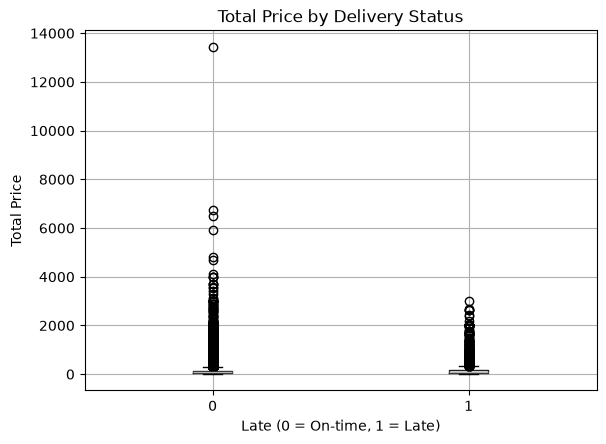

In [143]:
plt.figure(figsize=(8, 5))

train.boxplot(
    column="total_price",
    by="late"
)

plt.title("Total Price by Delivery Status")
plt.suptitle("")
plt.xlabel("Late (0 = On-time, 1 = Late)")
plt.ylabel("Total Price")

plt.show()

<Figure size 800x500 with 0 Axes>

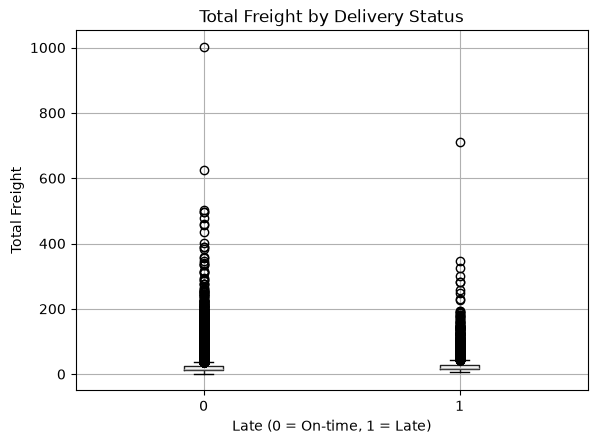

In [144]:
plt.figure(figsize=(8, 5))

train.boxplot(
    column="total_freight",
    by="late"
)

plt.title("Total Freight by Delivery Status")
plt.suptitle("")
plt.xlabel("Late (0 = On-time, 1 = Late)")
plt.ylabel("Total Freight")

plt.show()

<Figure size 800x500 with 0 Axes>

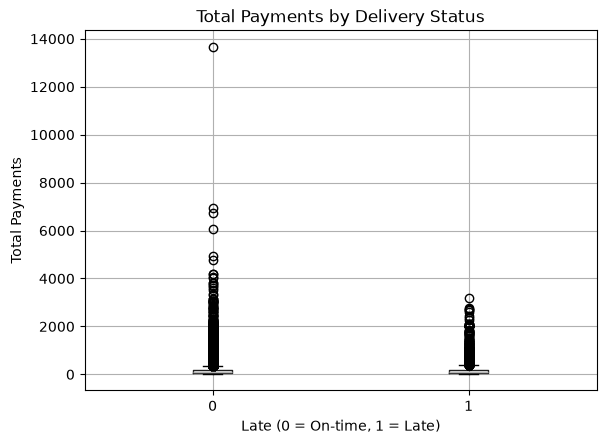

In [145]:
plt.figure(figsize=(8, 5))

train.boxplot(
    column="total_payments",
    by="late"
)

plt.title("Total Payments by Delivery Status")
plt.suptitle("")
plt.xlabel("Late (0 = On-time, 1 = Late)")
plt.ylabel("Total Payments")

plt.show()

<Figure size 800x500 with 0 Axes>

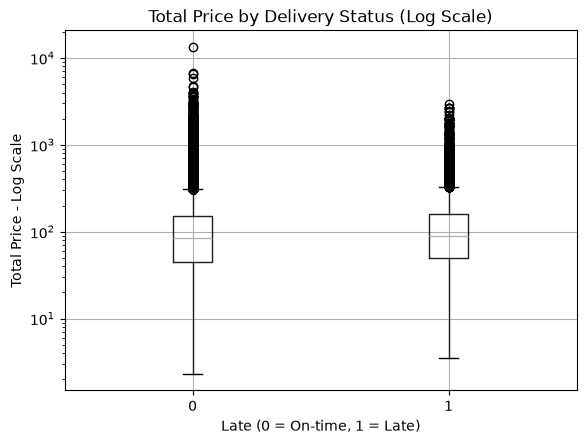

In [146]:
plt.figure(figsize=(8, 5))

train.boxplot(
    column="total_price",
    by="late"
)

plt.yscale("log")

plt.title("Total Price by Delivery Status (Log Scale)")
plt.suptitle("")
plt.xlabel("Late (0 = On-time, 1 = Late)")
plt.ylabel("Total Price - Log Scale")

plt.show()

<Figure size 800x500 with 0 Axes>

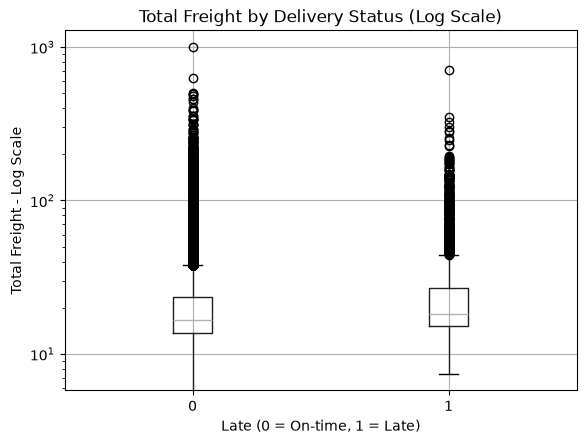

In [147]:
plt.figure(figsize=(8, 5))

train.boxplot(
    column="total_freight",
    by="late"
)

plt.yscale("log")

plt.title("Total Freight by Delivery Status (Log Scale)")
plt.suptitle("")
plt.xlabel("Late (0 = On-time, 1 = Late)")
plt.ylabel("Total Freight - Log Scale")

plt.show()

## 6. Late Delivery Rate by Order Characteristics

In [148]:
items_late_rate = (
    train.groupby("total_items")["late"]
    .agg(["count", "mean"])
)

items_late_rate["late_rate"] = items_late_rate["mean"] * 100

items_late_rate = items_late_rate.drop(columns="mean")

items_late_rate

,count,late_rate
total_items,,
1.0,60774,9.216112
2.0,5201,7.460104
3.0,903,6.866002
4.0,363,6.611570
5.0,134,8.955224
6.0,115,7.826087
7.0,13,0.000000
8.0,8,0.000000
9.0,3,0.000000


In [149]:
items_plot = items_late_rate[
    items_late_rate["count"] >= 50
].copy()

items_plot

,count,late_rate
total_items,,
1.0,60774,9.216112
2.0,5201,7.460104
3.0,903,6.866002
4.0,363,6.611570
5.0,134,8.955224
6.0,115,7.826087


### 6.1 Late Delivery by Order Status

In [150]:
pd.crosstab(
    train["order_status"],
    train["late"],
    margins=True
)

late,0,1,All
order_status,,,
canceled,5,1,6
delivered,61431,6096,67527
All,61436,6097,67533


### 6.2 Late Delivery Rate by State

In [151]:
state_late_rate = (
    train.groupby("customer_state")["late"]
    .agg(["count", "mean"])
)

state_late_rate["late_rate"] = (
    state_late_rate["mean"] * 100
)

state_late_rate = state_late_rate.drop(columns="mean")

state_late_rate.sort_values(
    "late_rate",
    ascending=False
)

,count,late_rate
customer_state,,
AL,298,27.852349
MA,548,21.532847
CE,948,18.248945
RR,29,17.241379
SE,246,17.073171
PI,348,16.666667
RJ,8967,16.583027
BA,2307,14.997833
PA,718,13.370474


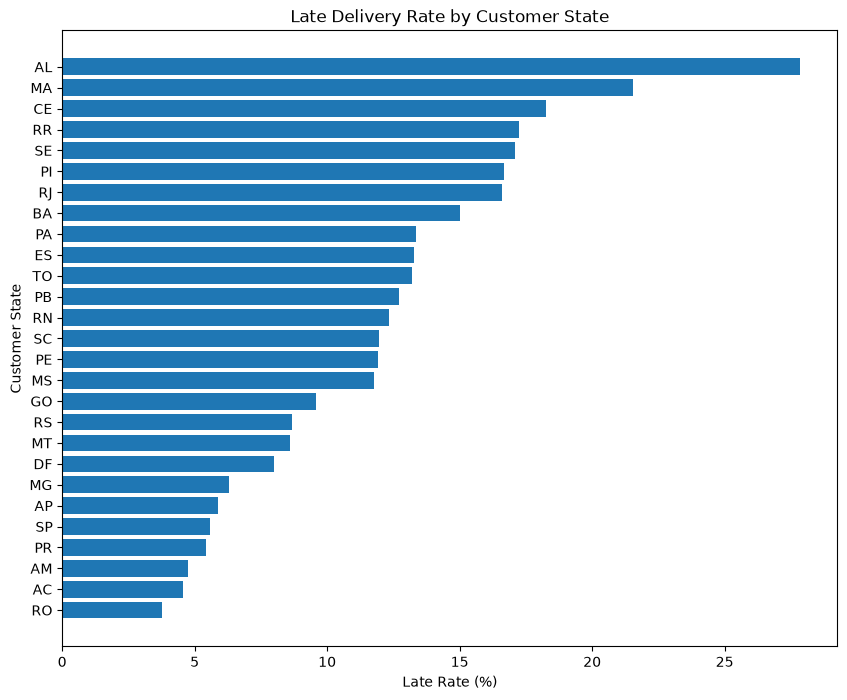

In [152]:
state_plot = state_late_rate.sort_values(
    "late_rate",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    state_plot.index,
    state_plot["late_rate"]
)

plt.xlabel("Late Rate (%)")
plt.ylabel("Customer State")
plt.title("Late Delivery Rate by Customer State")

plt.show()

## 7. Geographic Analysis

In [5]:
import sqlalchemy
from sqlalchemy import create_engine

DB_USER = "postgres"
DB_PASSWORD = input("Enter PostgreSQL password: ")
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "olist_db"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Connected successfully!")

Connected successfully!


In [7]:
import pandas as pd
# Read geolocation table from PostgreSQL

geolocation = pd.read_sql(
    "SELECT * FROM geolocation",
    engine
)

print("Geolocation shape:", geolocation.shape)
print(geolocation.head())

Geolocation shape: (1000163, 5)
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   
3                         1041       -23.544392       -46.639499   
4                         1035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


### 7.1 Inspect Geographic Coordinates

In [8]:
# Inspect geographic coordinates

geo_columns = [
    "geolocation_lat",
    "geolocation_lng"
]

print("Missing values:")
print(geolocation[geo_columns].isna().sum())

print("\nDescriptive statistics:")
print(geolocation[geo_columns].describe())

Missing values:
geolocation_lat    0
geolocation_lng    0
dtype: int64

Descriptive statistics:
       geolocation_lat  geolocation_lng
count     1.000163e+06     1.000163e+06
mean     -2.117615e+01    -4.639054e+01
std       5.715866e+00     4.269748e+00
min      -3.660537e+01    -1.014668e+02
25%      -2.360355e+01    -4.857317e+01
50%      -2.291938e+01    -4.663788e+01
75%      -1.997962e+01    -4.376771e+01
max       4.506593e+01     1.211054e+02


### 7.2 Aggregate Geographic Coordinates

In [9]:
# Aggregate geographic coordinates by ZIP code prefix

geo_features = (
    geolocation
    .groupby("geolocation_zip_code_prefix")
    [["geolocation_lat", "geolocation_lng"]]
    .mean()
    .reset_index()
)

print("Aggregated geolocation shape:", geo_features.shape)

print(
    "Duplicate ZIP prefixes:",
    geo_features["geolocation_zip_code_prefix"].duplicated().sum()
)

Aggregated geolocation shape: (19015, 3)
Duplicate ZIP prefixes: 0


In [15]:
geo_features.to_csv(
    "../data/artifacts/geo_features.csv",
    index=False
)

print("Geographic features saved successfully.")

Geographic features saved successfully.


### 7.3 Add Geographic Features to Training Data

In [12]:
# Temporarily add geographic coordinates to the training data

train_geo = train.merge(
    geo_features,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

print("Original train shape:", train.shape)
print("Train with geographic features:", train_geo.shape)

Original train shape: (67533, 21)
Train with geographic features: (67533, 24)


### 7.4 Geographic Features by Delivery Status

In [13]:
# Compare geographic coordinates by delivery status

geo_late_comparison = (
    train_geo
    .groupby("late")[[
        "geolocation_lat",
        "geolocation_lng"
    ]]
    .mean()
)

geo_late_comparison

,geolocation_lat,geolocation_lng
late,,
0,-21.242202,-46.285325
1,-20.007724,-45.089263


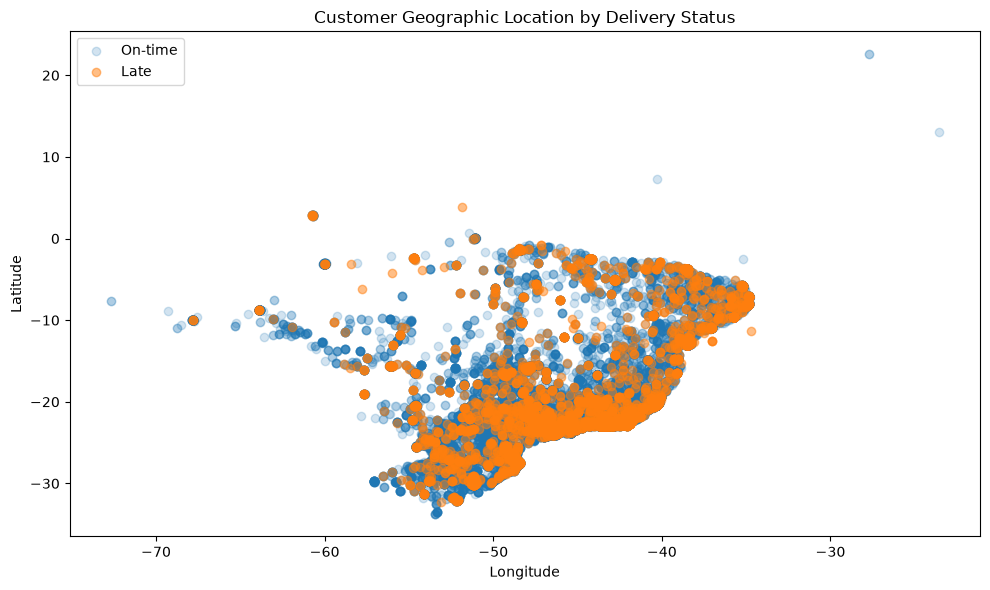

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_geo.loc[train_geo["late"] == 0, "geolocation_lng"],
    train_geo.loc[train_geo["late"] == 0, "geolocation_lat"],
    alpha=0.2,
    label="On-time"
)

plt.scatter(
    train_geo.loc[train_geo["late"] == 1, "geolocation_lng"],
    train_geo.loc[train_geo["late"] == 1, "geolocation_lat"],
    alpha=0.5,
    label="Late"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Customer Geographic Location by Delivery Status")
plt.legend()
plt.tight_layout()
plt.show()

### 7.5 City-Level Analysis

In [168]:
print("Unique cities:", train["customer_city"].nunique())

city_counts = train["customer_city"].value_counts()

print(city_counts.describe())

print("Cities with only 1 order:", (city_counts == 1).sum())
print("Cities with <= 5 orders:", (city_counts <= 5).sum())
print("Cities with <= 10 orders:", (city_counts <= 10).sum())

Unique cities: 3747
count    3747.000000
mean       18.023219
std       190.230195
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max      9921.000000
Name: count, dtype: float64
Cities with only 1 order: 1219
Cities with <= 5 orders: 2630
Cities with <= 10 orders: 3058


In [169]:
city_late_rate = (
    train.groupby("customer_city")["late"]
    .agg(["count", "mean"])
)

city_late_rate["late_rate"] = (
    city_late_rate["mean"] * 100
)

city_late_rate = city_late_rate.drop(columns="mean")

In [170]:
city_late_rate_reliable = city_late_rate[
    city_late_rate["count"] >= 50
].sort_values(
    "late_rate",
    ascending=False
)

city_late_rate_reliable.head(20)

,count,late_rate
customer_city,,
maceio,172,35.465116
sao goncalo,282,28.723404
sao joao de meriti,90,27.777778
cabo frio,94,26.595745
rio das ostras,97,23.711340
sao luis,244,23.360656
macae,155,23.225806
sao jose,114,22.807018
teresina,189,22.751323


In [171]:
city_late_rate_reliable.tail(20)

,count,late_rate
customer_city,,
mogi das cruzes,273,2.930403
aracatuba,103,2.912621
santana de parnaiba,105,2.857143
indaiatuba,185,2.702703
barueri,268,2.611940
sorocaba,404,2.475248
sao jose dos pinhais,82,2.439024
cotia,172,2.325581
aruja,51,1.960784


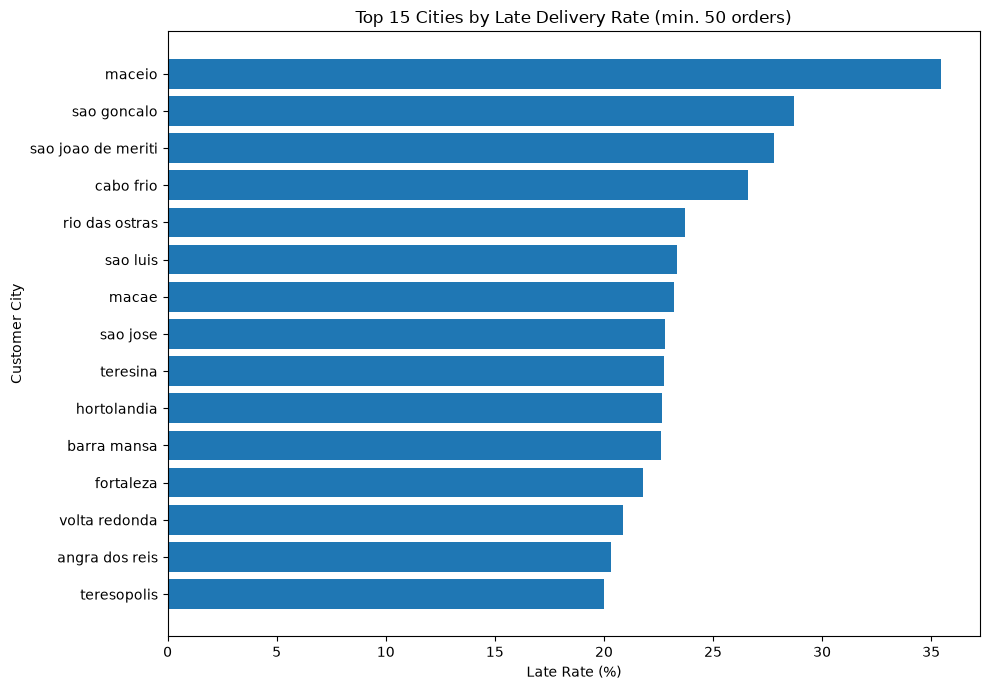

In [172]:
top_cities = city_late_rate_reliable.head(15).sort_values(
    "late_rate"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_cities.index,
    top_cities["late_rate"]
)

plt.xlabel("Late Rate (%)")
plt.ylabel("Customer City")
plt.title("Top 15 Cities by Late Delivery Rate (min. 50 orders)")

plt.tight_layout()
plt.show()

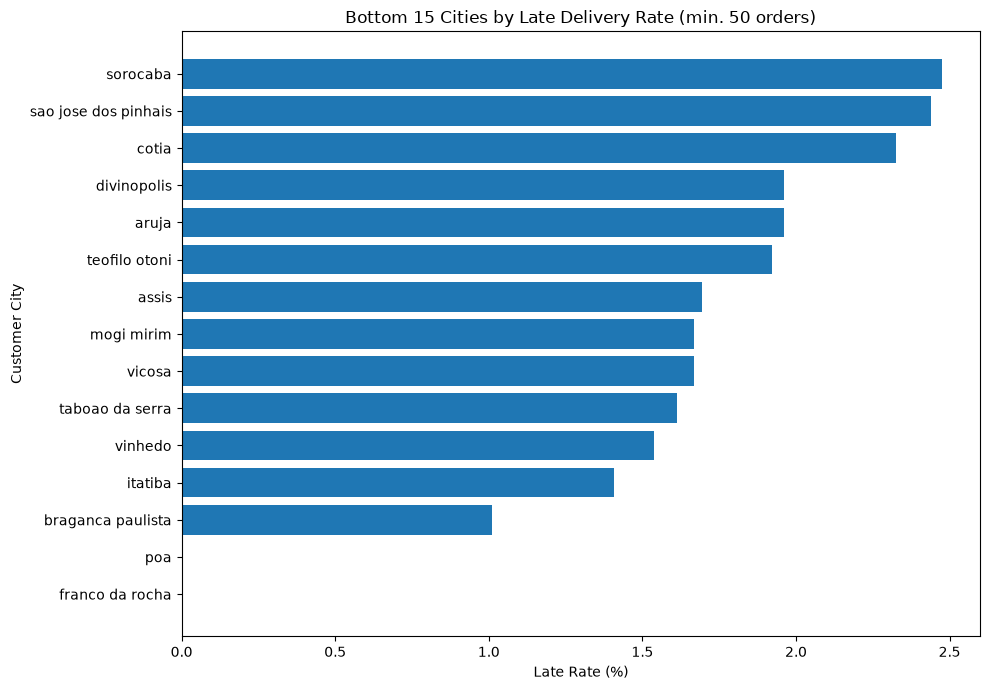

In [173]:
bottom_cities = city_late_rate_reliable.tail(15).sort_values(
    "late_rate"
)

plt.figure(figsize=(10, 7))

plt.barh(
    bottom_cities.index,
    bottom_cities["late_rate"]
)

plt.xlabel("Late Rate (%)")
plt.ylabel("Customer City")
plt.title("Bottom 15 Cities by Late Delivery Rate (min. 50 orders)")

plt.tight_layout()
plt.show()

## 8. Temporal Analysis

In [ ]:
train["order_purchase_timestamp"] = pd.to_datetime(
    train["order_purchase_timestamp"]
)

### 8.1 Yearly Late Delivery Rate

In [ ]:
train["purchase_year"] = (
    train["order_purchase_timestamp"].dt.year
)

year_late_rate = (
    train.groupby("purchase_year")["late"]
    .agg(["count", "mean"])
)

year_late_rate["late_rate"] = (
    year_late_rate["mean"] * 100
)

year_late_rate = year_late_rate.drop(
    columns="mean"
)

year_late_rate

,count,late_rate
purchase_year,,
2016,272,1.470588
2017,43426,6.627366
2018,23835,13.488567


### 8.2 Monthly Late Delivery Rate

In [176]:
train["purchase_year_month"] = (
    train["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_late_rate = (
    train.groupby("purchase_year_month")["late"]
    .agg(["count", "mean"])
)

monthly_late_rate["late_rate"] = (
    monthly_late_rate["mean"] * 100
)

monthly_late_rate = monthly_late_rate.drop(
    columns="mean"
)

monthly_late_rate

,count,late_rate
purchase_year_month,,
2016-09,1,100.000000
2016-10,270,1.111111
2016-12,1,0.000000
2017-01,750,3.066667
2017-02,1653,3.206292
2017-03,2546,5.577376
2017-04,2303,7.859314
2017-05,3545,3.610719
2017-06,3135,3.859649


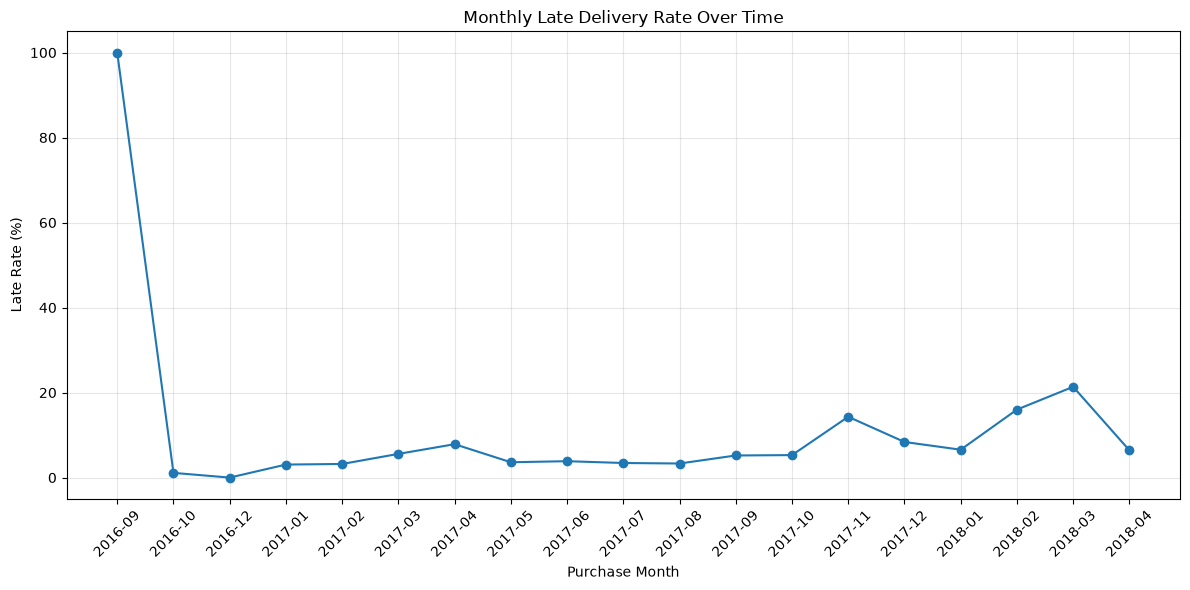

In [177]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_late_rate.index.astype(str),
    monthly_late_rate["late_rate"],
    marker="o"
)

plt.xlabel("Purchase Month")
plt.ylabel("Late Rate (%)")
plt.title("Monthly Late Delivery Rate Over Time")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 Day of Week and Hour Analysis

In [178]:
train["purchase_dayofweek"] = (
    train["order_purchase_timestamp"].dt.day_name()
)

train["purchase_hour"] = (
    train["order_purchase_timestamp"].dt.hour
)

In [179]:
dow_late_rate = (
    train.groupby("purchase_dayofweek")["late"]
    .agg(["count", "mean"])
)

dow_late_rate["late_rate"] = (
    dow_late_rate["mean"] * 100
)

dow_late_rate = dow_late_rate.drop(columns="mean")

dow_late_rate

,count,late_rate
purchase_dayofweek,,
Friday,9885,9.468892
Monday,10736,10.022355
Saturday,7594,8.967606
Sunday,8245,8.380837
Thursday,10005,8.285857
Tuesday,10729,9.264610
Wednesday,10339,8.608183


In [180]:
hour_late_rate = (
    train.groupby("purchase_hour")["late"]
    .agg(["count", "mean"])
)

hour_late_rate["late_rate"] = (
    hour_late_rate["mean"] * 100
)

hour_late_rate = hour_late_rate.drop(columns="mean")

hour_late_rate

,count,late_rate
purchase_hour,,
0,1662,9.687124
1,837,8.841099
2,370,7.837838
3,186,4.838710
4,136,7.352941
5,134,8.208955
6,318,8.176101
7,806,8.064516
8,1951,8.508457
